Redes Neurais Convolucionais (CNNs) são algoritmos de aprendizado profundo especializados em analisar dados visuais, como imagens e vídeos, para tarefas de visão computacional.

# Modelo pln, com o processamento de linguagem natural. 

In [72]:
import spacy # verificar a versão atual 
spacy.__version__  

'3.8.7'

In [73]:
import pandas as pd
import string
import spacy
import random
import seaborn as sns
import numpy as np

### 26.3) idicativo das frases através dos modelos
### Etapa 6: Testes com uma frase

In [74]:
# carregando o modelo, salvo no arquivo da memória, e em uma pasta
modelo_carregado = spacy.load("modelo_spacy")
modelo_carregado

In [75]:
# texto positivo
texto_positivo = 'eu adoro cor dos seus olhos'

In [76]:
from spacy.lang.pt.stop_words import STOP_WORDS
stop_words = STOP_WORDS

In [77]:
pontuacoes = string.punctuation
pontuacoes

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [78]:
# vamos fazer o reprocessamento, elaborado no programa M24-7
def preprocessamento(texto):
  texto = texto.lower()
  documento = pln(texto)

  lista = []
  for token in documento:
    #lista.append(token.text)
    lista.append(token.lemma_)

  lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in pontuacoes]
  lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])

  return lista

In [79]:
#pln = spacy.load('pt')
pln = spacy.load("pt_core_news_sm")

In [80]:
texto_positivo = preprocessamento(texto_positivo)
texto_positivo

'adorar cor de o olho'

In [81]:
# faremos a variável previsão

In [82]:
previsao = modelo_carregado(texto_positivo)
previsao

adorar cor de o olho

In [83]:
# vamos mostrar as categorias, definicas como dicionário anteriormente, para ver a classificação

In [84]:
previsao.cats

{'ALEGRIA': 1.0, 'MEDO': 1.5366946826134154e-08}

In [85]:
previsao.cats['ALEGRIA']

1.0

In [86]:
### Buscando a probabilidade que tem o maior valor
if previsao.cats['ALEGRIA'] > previsao.cats['MEDO']:
    print(f'a frase é de ALEGRIA, com uma probabilidade de {previsao.cats['ALEGRIA']}')
elif previsao.cats['ALEGRIA'] < previsao.cats['MEDO']:
    print(f'a frase é de medo, com uma probabilidade de {previsao.cats['MEDO']}')


a frase é de ALEGRIA, com uma probabilidade de 1.0


In [87]:
texto_negativo = 'estou com medo dele'
previsao = modelo_carregado(preprocessamento(texto_negativo))
previsao.cats

{'ALEGRIA': 8.398419595323503e-07, 'MEDO': 0.9999991655349731}

In [88]:
### Buscando a probabilidade que tem o maior valor
if previsao.cats['ALEGRIA'] > previsao.cats['MEDO']:
    print(f'a frase é de ALEGRIA, com uma probabilidade de {previsao.cats['ALEGRIA']}')
elif previsao.cats['ALEGRIA'] < previsao.cats['MEDO']:
    print(f'a frase é de medo, com uma probabilidade de {previsao.cats['MEDO']}')

a frase é de medo, com uma probabilidade de 0.9999991655349731


In [89]:
# dados para teste como funciona

In [90]:
texto = 'amor da vida da gente'
previsao = modelo_carregado(preprocessamento(texto))
print(f'texto {texto}')
print(previsao.cats)
### Buscando a probabilidade que tem o maior valor
if previsao.cats['ALEGRIA'] > previsao.cats['MEDO']:
    print(f'a frase é de ALEGRIA, com uma probabilidade de {previsao.cats['ALEGRIA']}')
elif previsao.cats['ALEGRIA'] < previsao.cats['MEDO']:
    print(f'a frase é de medo, com uma probabilidade de {previsao.cats['MEDO']}')

texto amor da vida da gente
{'ALEGRIA': 0.9999998807907104, 'MEDO': 1.4281019389272842e-07}
a frase é de ALEGRIA, com uma probabilidade de 0.9999998807907104


In [91]:
base_dados = pd.read_csv('base_treinamento.txt', encoding = 'utf-8')
base_dados.head()

,texto,emocao
0,este trabalho é agradável,alegria
1,gosto de ficar no seu aconchego,alegria
2,fiz a adesão ao curso hoje,alegria
3,eu sou admirada por muitos,alegria
4,adoro como você,alegria


In [92]:
previsoes = []
for texto in base_dados['texto']:
  #print(texto)
  previsao = modelo_carregado(texto)
  previsoes.append(previsao.cats)

In [93]:
previsoes[:5] # valores altos na alegria nos primeiros valores

[{'ALEGRIA': 0.9999986886978149, 'MEDO': 1.3169488966013887e-06},
 {'ALEGRIA': 0.9992436170578003, 'MEDO': 0.0007564274710603058},
 {'ALEGRIA': 0.9999988079071045, 'MEDO': 1.2455407158995513e-06},
 {'ALEGRIA': 0.2301865667104721, 'MEDO': 0.7698134779930115},
 {'ALEGRIA': 0.99997878074646, 'MEDO': 2.1231526261544786e-05}]

In [94]:
previsoes_final = []
for previsao in previsoes:
  if previsao['ALEGRIA'] > previsao['MEDO']:
    previsoes_final.append('alegria')
  else:
    previsoes_final.append('medo')

previsoes_final = np.array(previsoes_final)

In [95]:
previsoes_final

array(['alegria', 'alegria', 'alegria', 'medo', 'alegria', 'alegria',
       'alegria', 'medo', 'alegria', 'alegria', 'alegria', 'medo',
       'alegria', 'alegria', 'medo', 'alegria', 'medo', 'alegria',
       'alegria', 'alegria', 'medo', 'medo', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'medo', 'alegria', 'alegria', 'medo',
       'alegria', 'medo', 'alegria', 'medo', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'medo', 'alegria',
       'alegria', 'medo', 'alegria', 'alegria', 'medo', 'alegria',
       'alegria', 'medo', 'medo', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'medo',
       'alegria', 'alegria', 'medo', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'al

In [96]:
len(previsoes_final), len(base_dados)

(196, 196)

In [97]:
from collections import Counter

quantidade_alegria = Counter(previsoes_final)
print(f" Alegria foram {quantidade_alegria['alegria']} vezes.")

 Alegria foram 105 vezes.


In [98]:
quantidade_alegria

Counter({np.str_('alegria'): 105, np.str_('medo'): 91})

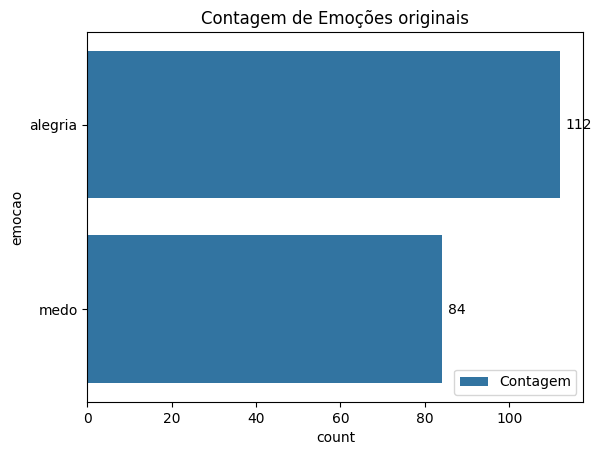

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the countplot and store it in a variable (e.g., 'ax')a
ax = sns.countplot(y='emocao', data=base_dados, label='Contagem')

# 2. Iterate over the bar containers and add the label
# ax.containers holds the list of BarContainer objects for the plot
# Since it's a simple countplot, there's usually just one container (ax.containers[0])
# but iterating is safer, especially if you were to add 'hue'.

for container in ax.containers:
    # ax.bar_label() is a Matplotlib function to add labels to bars.
    # It works for horizontal and vertical plots.
    # For horizontal plots, it places the label near the end of the bar.
    ax.bar_label(container, fmt='%d', padding=4.2) # padding adds a small space between the bar and the label

# Optional: Add a title and show the plot
plt.title('Contagem de Emoções originais')
plt.show()

In [100]:
respostas_reais = base_dados['emocao'].values
respostas_reais

array(['alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 

In [101]:
# verificar a acurácia da previsão com o valor real
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy_score(respostas_reais, previsoes_final)

0.8112244897959183

In [102]:
acuracia = accuracy_score(respostas_reais, previsoes_final)
print(f'Acurácia {acuracia*100:.2f} %') # se for ter valores 100% pode haver overfitting, o modelo se adapta muito aos dados. 

Acurácia 81.12 %


In [103]:
cm = confusion_matrix(respostas_reais, previsoes_final)
cm

array([[90, 22],
       [15, 69]])

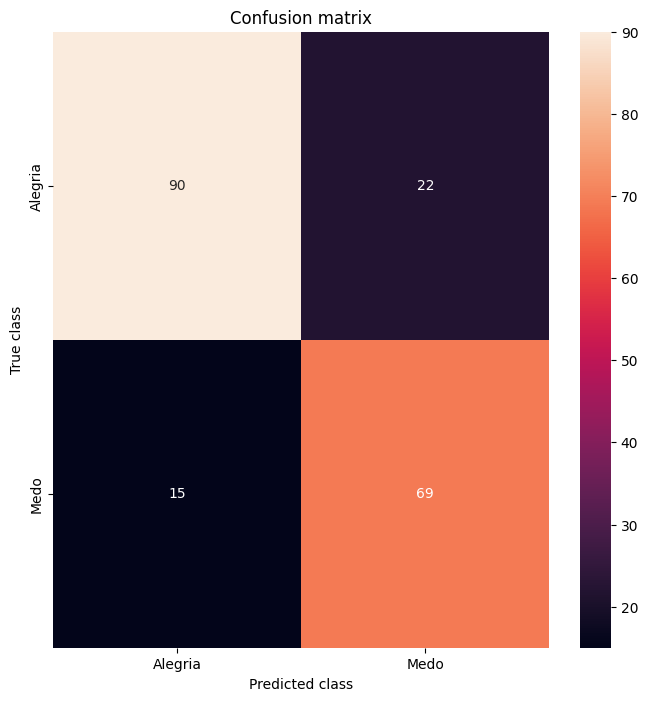

In [104]:
LABELS = ["Alegria", "Medo"]

plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [105]:
#| acertos de alegria |  erros   |
#| erros              | acertos  de medo|

## Avaliação na base de teste

# 26.5) Sentimento Spacy 

In [106]:
base_dados_teste = pd.read_csv('base_teste.txt', encoding = 'utf-8')

In [107]:
base_dados_teste.head()

,texto,emocao
0,não precisei pagar o ingresso,alegria
1,se eu ajeitar tudo fica bem,alegria
2,minha fortuna ultrapassará a sua,alegria
3,sou muito afortunado,alegria
4,é benéfico para todos esta nova medida,alegria


In [108]:
base_dados_teste['texto'] = base_dados_teste['texto'].apply(preprocessamento)

In [109]:
base_dados_teste.head()

,texto,emocao
0,precisar pagar ingresso,alegria
1,ajeitar ficar,alegria
2,fortuna ultrapassar,alegria
3,afortunar,alegria
4,benéfico medida,alegria


In [110]:
previsoes = []
for texto in base_dados_teste['texto']:
  #print(texto)
  previsao = modelo_carregado(texto)
  previsoes.append(previsao.cats)

In [111]:
previsoes[:5]

[{'ALEGRIA': 4.674235242418945e-06, 'MEDO': 0.9999953508377075},
 {'ALEGRIA': 0.5765633583068848, 'MEDO': 0.4234366714954376},
 {'ALEGRIA': 0.0027934543322771788, 'MEDO': 0.9972065091133118},
 {'ALEGRIA': 1.0, 'MEDO': 1.9341273471695786e-08},
 {'ALEGRIA': 0.860207736492157, 'MEDO': 0.13979224860668182}]

In [112]:
previsoes_final = []
for previsao in previsoes:
  if previsao['ALEGRIA'] > previsao['MEDO']:
    previsoes_final.append('alegria')
  else:
    previsoes_final.append('medo')

previsoes_final = np.array(previsoes_final)

In [113]:
previsoes_final

array(['medo', 'alegria', 'medo', 'alegria', 'alegria', 'alegria', 'medo',
       'alegria', 'alegria', 'alegria', 'medo', 'medo', 'medo', 'alegria',
       'alegria', 'medo', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'medo', 'medo', 'alegria', 'medo', 'alegria', 'alegria',
       'alegria', 'medo', 'medo', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'medo', 'alegria', 'medo', 'medo', 'alegria', 'alegria', 'medo',
       'medo', 'alegria', 'alegria', 'medo', 'alegria', 'medo', 'alegria',
       'alegria', 'alegria', 'medo', 'medo', 'medo', 'medo', 'medo',
       'medo', 'medo', 'alegria', 'medo', 'alegria', 'medo', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo',
       'alegria', 'alegria', 'medo', 'alegria'], dtype='<U7')

In [114]:
from collections import Counter

quantidade_alegria = Counter(previsoes_final)
print(f" Alegria foram {quantidade_alegria['alegria']} vezes.")

 Alegria foram 49 vezes.


In [115]:
quantidade_alegria

Counter({np.str_('alegria'): 49, np.str_('medo'): 35})

In [116]:
respostas_reais = base_dados_teste['emocao'].values

In [120]:
respostas_reais

array(['alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo',
       'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo',
       'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo',
       'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo', 'medo',
       'medo', 'medo', 'medo', 'medo'], dtype=object)

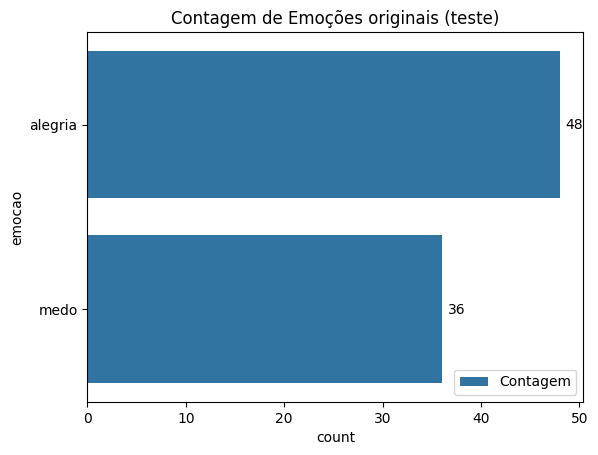

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the countplot and store it in a variable (e.g., 'ax')a
ax = sns.countplot(y='emocao', data=base_dados_teste, label='Contagem')

# 2. Iterate over the bar containers and add the label
# ax.containers holds the list of BarContainer objects for the plot
# Since it's a simple countplot, there's usually just one container (ax.containers[0])
# but iterating is safer, especially if you were to add 'hue'.

for container in ax.containers:
    # ax.bar_label() is a Matplotlib function to add labels to bars.
    # It works for horizontal and vertical plots.
    # For horizontal plots, it places the label near the end of the bar.
    ax.bar_label(container, fmt='%d', padding=4.2) # padding adds a small space between the bar and the label

# Optional: Add a title and show the plot
plt.title('Contagem de Emoções originais (teste)')
plt.show()

In [119]:
accuracy_score(respostas_reais, previsoes_final)

0.5833333333333334

In [121]:
acuracia = accuracy_score(respostas_reais, previsoes_final)
print(f'Acurácia {acuracia*100:.2f} %') # se for ter valores 100% pode haver overfitting, o modelo se adapta muito aos dados. 

Acurácia 58.33 %


In [122]:
cm = confusion_matrix(respostas_reais, previsoes_final)
cm

array([[31, 17],
       [18, 18]])

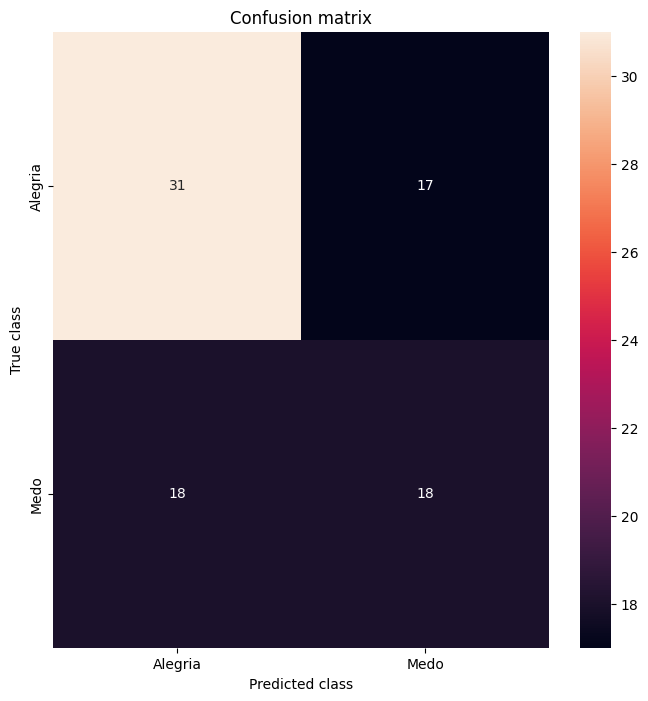

In [123]:
LABELS = ["Alegria", "Medo"]

plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [124]:
#| acertos de alegria |  erros   |
#| erros              | acertos  de medo|

In [125]:
# mostrando uma visão geral do spacy